#Install Libaries & Get data

In [1]:
import torch
from transformers import SegformerConfig, SegformerForSemanticSegmentation

# Check if GPU is available
#device = torch.device("cpu" if torch.backends.mps.is_available() else "cpu")

#use cuda t4 gpu when using google colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# run this cell only if using google colab to mount to drive

from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torch.nn.functional import relu

# Get Dataset from Kaggle and Process Masks

text

#Dataset and Dataloaders

In [ ]:
import rasterio
import numpy as np
import os
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms
import numpy as np
import torch.nn.functional as F


def load_and_preprocess(path):
    with rasterio.open(path) as src:
        # Read all bands
        img = src.read()

        # Replace No-Data (example: -9999) with 0
        img[img == src.nodata] = 0

        # Robust Scaling (2nd and 98th percentile to remove outliers)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip(img, p2, p98)
        img = (img - p2) / (p98 - p2)

    return img.astype(np.float32)

# Helper function to load raw mask data (without scaling or robust percentile clipping)
# Assumes single-channel mask where pixel values are class labels
def load_raw_mask(path):
    with rasterio.open(path) as src:
        mask_np = src.read()
        # Replace No-Data with 4 (or a specific background class ID)
        if src.nodata is not None:
            mask_np[mask_np == src.nodata] = 4

        # Recode classes 2 and 3 to 0
        #mask_np[mask_np == 2] = 0
        #mask_np[mask_np == 3] = 0
    return mask_np.astype(np.int64) # Masks are typically integer class labels

def get_filename_without_extension(file_path):
    # Extract the base name (filename + extension) from the full path
    base_name = os.path.basename(file_path)
    # Split the base name into root and extension, and return the root
    file_name_without_extension = os.path.splitext(base_name)[0]
    return file_name_without_extension

def one_hot_encode_mask(mask_tensor, num_classes, target_size):
    # Ensure mask_tensor is on CPU for one_hot operation if it's on GPU
    mask_tensor = mask_tensor.cpu() # mask_tensor is (1, H, W) from load_raw_mask

    # Squeeze the channel dimension to get (H, W) before resizing
    # Then, add a channel dimension (1, H, W) for transforms.Resize to operate correctly on spatial dimensions,
    # and squeeze it back to (H_new, W_new) after resizing.
    resized_mask_with_channel = transforms.Resize(target_size, interpolation=transforms.InterpolationMode.NEAREST)(
        mask_tensor.squeeze(0).unsqueeze(0) # (H, W) -> (1, H, W) for Resize input
    )
    resized_mask = resized_mask_with_channel.squeeze(0).long() # (H_new, W_new) after removing the temporary channel dim

    # Perform one-hot encoding on the (H_new, W_new) tensor
    # Output will be (H_new, W_new, num_classes)
    one_hot_mask = F.one_hot(resized_mask, num_classes=num_classes)

    # Reshape to (num_classes, H, W) for consistency with model output
    one_hot_mask = one_hot_mask.permute(2, 0, 1).float()
    return one_hot_mask

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np
from torchvision import transforms # Make sure this is imported if used later in __getitem__

class TrainingDataset(Dataset):
    def __init__(self, image_paths, label_paths, processor, num_classes=5):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.processor = processor # Store the processor
        self.num_classes = num_classes
        # Add a placeholder for transform, if it's expected to be used
        # If the processor handles all transforms, this might not be needed.
        self.transform = None # The processor usually handles all transformations
        print(f"TrainingDataset initialized for {self.num_classes}-class segmentation using SegformerImageProcessor.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_np = load_and_preprocess(self.image_paths[index])

        # Ensure image_np has channels first (C, H, W) as expected by the following logic
        # If load_and_preprocess returns (H, W, C), you might need to transpose here:
        # if image_np.shape[2] == 3 or image_np.shape[2] == 4:
        #     image_np = image_np.transpose(2, 0, 1)

        # Convert image_np (C, H, W) to a PIL Image (H, W, C) for torchvision transforms
        # which expect PIL Image for operations like Resize. Also handle 4 channels.
        if image_np.shape[0] == 3: # Assuming RGB
            image_pil = Image.fromarray((image_np.transpose(1, 2, 0) * 255).astype(np.uint8))
        elif image_np.shape[0] == 4: # Assuming RGB-NIR, take only RGB
            # Select the first 3 channels (R, G, B) and transpose for PIL
            image_pil = Image.fromarray((image_np[:3, :, :].transpose(1, 2, 0) * 255).astype(np.uint8))
        elif image_np.shape[0] == 1: # Assuming grayscale
            image_pil = Image.fromarray((image_np.squeeze(0) * 255).astype(np.uint8))
        else:
            raise ValueError(f"Unsupported image channel count: {image_np.shape[0]} for PIL conversion")

        # Apply the image transform (includes Resize, ToTensor, Normalize)
        # Note: self.transform is set to None, so this block won't execute unless transform is added
        if self.transform:
            image_tensor = self.transform(image_pil)
        else:
            # If no transform is provided, at least convert to tensor
            # This part is effectively bypassed if processor is used directly below.
            # image_tensor = transforms.ToTensor()(image_pil)
            pass # No direct tensor conversion here, processor will do it.

        mask_np_raw = load_raw_mask(self.label_paths[index]) # Returns (1, H, W) numpy array
        #create_multi_label_mask(self.label_paths[index])

        # Use the processor to prepare inputs
        # The processor handles resizing, normalization, and converting to tensors
        # reduce_labels=False is crucial to keep our 5 classes
        encoded_inputs = self.processor(images=image_pil, segmentation_maps=mask_np_raw, return_tensors="pt", reduce_labels=False)

        # The processor returns a dictionary with 'pixel_values' and 'labels'
        # Labels need to be of type long for CrossEntropyLoss. SegformerImageProcessor already does this.
        # It also handles resizing the mask using nearest neighbor.

        return {
            "pixel_values": encoded_inputs["pixel_values"].squeeze(0), # Remove batch dim added by processor
            "labels": encoded_inputs["labels"].squeeze(0) # Remove batch dim added by processor
        }

In [ ]:
import os
import glob
import random
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from transformers import SegformerImageProcessor # Import the processor
import torch
import numpy as np

def get_data_loaders(batch_size=4, subset_size=None, undersampling_ratio=0.0, minority_class_threshold=0.2, return_dataset = False, use_pre_disaster= False):
    base_path = '/content/drive/MyDrive/12/SP/damage/haiti'#'/Users/yujiewu/SP/haiti_cropped_smaller'
    image_dir = os.path.join(base_path, 'images')
    label_dir = os.path.join(base_path, 'labels')
    if(use_pre_disaster):
        #image_dir = os.path.join(base_path, 'images-pre-disaster') # for localization transfer learning
        label_dir = os.path.join(base_path, 'labels-pre-disaster') # for localization transfer learning

    all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*.tif')))
    all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*.tif')))
    print(f"Found {len(all_image_paths)} images and {len(all_label_paths)} labels.")
    if len(all_image_paths) != len(all_label_paths):
        raise ValueError("Mismatch between number of images and labels.")

    all_pairs = list(zip(all_image_paths, all_label_paths))
    train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

    if subset_size is not None:
        train_pairs = train_pairs[:subset_size]
        val_pairs = val_pairs[:subset_size // 4]

    train_image_paths = [p[0] for p in train_pairs]
    train_label_paths = [p[1] for p in train_pairs]

    val_image_paths = [p[0] for p in val_pairs]
    val_label_paths = [p[1] for p in val_pairs]

    print(f"Training images: {len(train_image_paths)}")
    print(f"Validation images: {len(val_image_paths)}")

    # Use the globally defined processor from cell 92nFBocyPezd
    global processor

    train_dataset = TrainingDataset(
        image_paths=train_image_paths,
        label_paths=train_label_paths,
        processor=processor # Pass the processor
    )

    val_dataset = TrainingDataset(
        image_paths=val_image_paths,
        label_paths=val_label_paths,
        processor=processor # Pass the processor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )
    # Return the datasets instead of dataloaders
    if return_dataset:
      return {'train': train_dataset, 'val': val_dataset}
    else:
      return {'train': train_loader, 'val': val_loader}

print("Function `get_data_loaders` defined using SegformerImageProcessor.")


Function `get_data_loaders` defined using SegformerImageProcessor.


#Model Setup

In [ ]:
#pretrained
# We'll use the 'mit-b0' variant fine-tuned on the ADE20k dataset
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"

# Load the model and move it to the GPU
model = SegformerForSemanticSegmentation.from_pretrained(model_name)
model.to(device)

print("Pre-trained model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Pre-trained model loaded successfully!


In [ ]:
from transformers import SegformerImageProcessor

# Use the same checkpoint name you used for the model
checkpoint = "nvidia/segformer-b0-finetuned-ade-512-512"

# Load the processor
# Set do_rescale=False because images are already scaled by load_and_preprocess
# Set do_reduce_labels=False to keep all 5 damage classes
processor = SegformerImageProcessor.from_pretrained(checkpoint, do_rescale=False, do_reduce_labels=False)

print(processor)

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

SegformerImageProcessor {
  "do_normalize": true,
  "do_reduce_labels": false,
  "do_rescale": false,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "SegformerImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 512,
    "width": 512
  }
}



/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


In [ ]:
from transformers import TrainingArguments

epochs = 30
lr = 0.00006
batch_size = 2

hub_model_id = "segformer-earthquake-damage-assessment"

training_args = TrainingArguments(
    #"segformer-b0-finetuned-segments-sidewalk-outputs",
    learning_rate=lr,
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    save_total_limit=3,
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    load_best_model_at_end=True,
    push_to_hub=False,
    hub_model_id=hub_model_id,
    hub_strategy="end",
    use_cpu=False
)

In [ ]:
id2label = {
    0: "un-classified",
    1: "no-damage",
    2: "minor-damage",
    3: "major-damage",
    4: "destroyed" # This mapping is consistent with the damage_to_idx from create_multi_label_mask
}

label2id = {v: k for k, v in id2label.items()}

id2label_localization = {0: "background", 1: "road"}
label2id_localization = {"background": 0, "road": 1}


In [ ]:
#if kernel is colab, run this

!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00


In [ ]:
import torch
from torch import nn
import evaluate

metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
  with torch.no_grad():
    logits, labels = eval_pred
    logits_tensor = torch.from_numpy(logits)
    # scale the logits to the size of the label
    logits_tensor = nn.functional.interpolate(
        logits_tensor,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False,
    ).argmax(dim=1)

    pred_labels = logits_tensor.detach().cpu().numpy()
    metrics = metric.compute(
        predictions=pred_labels,
        references=labels,
        num_labels=len(id2label),
        ignore_index=0,
        reduce_labels=processor.do_reduce_labels,
    )

    # add per category metrics as individual key-value pairs
    per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
    per_category_iou = metrics.pop("per_category_iou").tolist()

    metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
    metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})

    return metrics
  

def compute_metrics_localization(eval_pred):
  with torch.no_grad():
    logits, labels = eval_pred
    logits_tensor = torch.from_numpy(logits)
    # scale the logits to the size of the label
    logits_tensor = nn.functional.interpolate(
        logits_tensor,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False,
    ).argmax(dim=1)

    pred_labels = logits_tensor.detach().cpu().numpy()
    metrics = metric.compute(
        predictions=pred_labels,
        references=labels,
        num_labels=len(id2label_localization),
        ignore_index=0,
        reduce_labels=processor.do_reduce_labels,
    )

    # add per category metrics as individual key-value pairs
    per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
    per_category_iou = metrics.pop("per_category_iou").tolist()

    metrics.update({f"accuracy_{id2label_localization[i]}": v for i, v in enumerate(per_category_accuracy)})
    metrics.update({f"iou_{id2label_localization[i]}": v for i, v in enumerate(per_category_iou)})

    return metrics

In [ ]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "nvidia/mit-b0"

# Define ID to Label and Label to ID mappings for 5-class damage segmentation
num_labels = len(id2label) # Should be 5
num_labels_localization = len(id2label_localization) # Should be 2

#model = SegformerForSemanticSegmentation.from_pretrained(
#    pretrained_model_name,
#    num_labels=num_labels,
#    id2label=id2label,
#    label2id=label2id
#)
model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    num_labels=num_labels_localization , # Use the same number of classes for localization transfer learning
    id2label=id2label_localization, # Use localization label mapping
    label2id=label2id_localization # Use localization label mapping
)
model.to(device)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

In [ ]:
from transformers import Trainer

dataloader = get_data_loaders(return_dataset = True, use_pre_disaster=True) # Use pre-disaster images for localization transfer learning

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataloader["train"],
    eval_dataset=dataloader["val"],
    compute_metrics=compute_metrics_localization,
)

trainer.train()

Found 352 images and 352 labels.
Training images: 281
Validation images: 71
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.


/usr/local/lib/python3.12/dist-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


Step,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Overall Accuracy,Accuracy Background,Accuracy Road,Iou Background,Iou Road
20,0.491507,0.500653,0.449512,0.899023,0.899023,nan,0.899023,0.000000,0.899023
40,0.465718,0.473244,0.472342,0.944684,0.944684,nan,0.944684,0.000000,0.944684
60,0.467226,0.401136,0.441859,0.883719,0.883719,nan,0.883719,0.000000,0.883719
80,0.400978,0.389421,0.431494,0.862989,0.862989,nan,0.862989,0.000000,0.862989
100,0.405317,0.460852,0.325152,0.650304,0.650304,nan,0.650304,0.000000,0.650304
120,0.437779,0.369218,0.431528,0.863056,0.863056,nan,0.863056,0.000000,0.863056
140,0.339935,0.353505,0.436028,0.872056,0.872056,nan,0.872056,0.000000,0.872056
160,0.340315,0.459590,0.477715,0.955429,0.955429,nan,0.955429,0.000000,0.955429
180,0.636116,0.365077,0.400297,0.800595,0.800595,nan,0.800595,0.000000,0.800595
200,0.365345,0.334289,0.434867,0.869735,0.869735,nan,0.869735,0.000000,0.869735


/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)



PHASE 2: Transfer Learning - Damage Classification

Loading best model from Phase 1: trainer_output/checkpoint-2240


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: trainer_output/checkpoint-2240
Key                           | Status   |                                                                                                 
------------------------------+----------+-------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([5])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 256, 1, 1]) vs model:torch.Size([5, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model reloaded with 5 damage classes!
Training images: 281
Validation images: 71
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.

Phase 2 data loaded:
  Training samples: 281
  Validation samples: 71

Starting Phase 2 training on damage classification...


/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


...

/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)
/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/datasets/features/image.py:377: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/Users/yujiewu/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Phase 2 Training Complete!


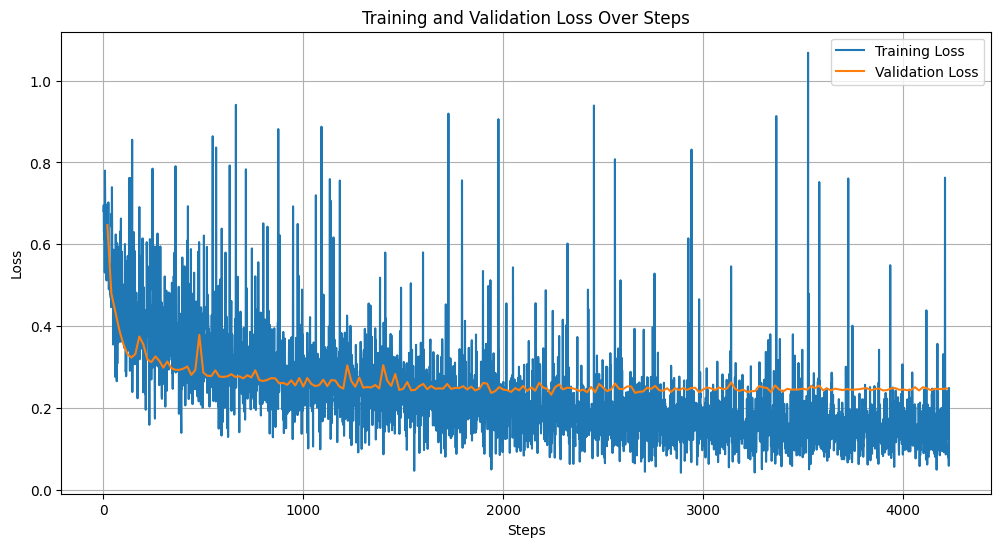

"\n# Plotting evaluation metrics\nplt.figure(figsize=(12, 8))\nfor metric_name, values in eval_metrics.items():\n    if values: # Only plot if there are values for the metric\n        plt.plot(eval_steps, values, label=metric_name)\n\nplt.xlabel('Steps')\nplt.ylabel('Metric Value')\nplt.title('Validation Metrics Over Steps')\nplt.legend()\nplt.grid(True)\nplt.show()\n"

In [ ]:
# ===== PHASE 2: FINE-TUNE ON DAMAGE CLASSIFICATION (5 CLASSES) =====
print("\n" + "="*80)
print("PHASE 2: Transfer Learning - Damage Classification")
print("="*80)

# Load the best model from Phase 1 (localization)
best_model_path = trainer.state.best_model_checkpoint
print(f"\nLoading best model from Phase 1: {best_model_path}")

# Reload the model with 5 damage classes instead of 2 localization classes
model_phase2 = SegformerForSemanticSegmentation.from_pretrained(
    best_model_path,
    num_labels=len(id2label),  # 5 damage classes
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True  # Allow size mismatch in decoder head for different num_labels
)
model_phase2.to(device)
print("Model reloaded with 5 damage classes!")

# Create new training arguments for Phase 2 (damage classification)
# Use a smaller learning rate for fine-tuning on the new task
training_args_phase2 = TrainingArguments(
    learning_rate=1e-5,  # Smaller learning rate for fine-tuning
    num_train_epochs=15,  # Fewer epochs since we're fine-tuning
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    save_total_limit=3,
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    load_best_model_at_end=True,
    push_to_hub=False,
    hub_model_id="segformer-earthquake-damage-classification",
    hub_strategy="end",
    use_cpu=False,
    output_dir="./trainer_phase2"
)

# Load data for Phase 2: post-disaster images with damage labels (5 classes)
dataloader_phase2 = get_data_loaders(return_dataset=True, use_pre_disaster=False)
print(f"\nPhase 2 data loaded:")
print(f"  Training samples: {len(dataloader_phase2['train'])}")
print(f"  Validation samples: {len(dataloader_phase2['val'])}")

# Create trainer for Phase 2
trainer_phase2 = Trainer(
    model=model_phase2,
    args=training_args_phase2,
    train_dataset=dataloader_phase2["train"],
    eval_dataset=dataloader_phase2["val"],
    compute_metrics=compute_metrics,  # Use damage metrics (5 classes)
)

print("\nStarting Phase 2 training on damage classification...")
trainer_phase2.train()

print("\n" + "="*80)
print("Phase 2 Training Complete!")
print("="*80)

import matplotlib.pyplot as plt

# Extract training and evaluation logs
log_history = trainer.state.log_history

train_losses = []
eval_losses = []
steps = []

# Metrics to plot
eval_metrics = {
    'eval_loss': [],
    'eval_mean_iou': [],
    'eval_accuracy_background': [],
    'eval_accuracy_road': [],
    'eval_iou_background': [],
    'eval_iou_road': [],
}

for log in log_history:
    if 'loss' in log: # Training loss
        train_losses.append(log['loss'])
        steps.append(log['step'])
    if 'eval_loss' in log: # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        for key in eval_metrics.keys():
            if key in log:
                eval_metrics[key].append(log[key])

# Plotting training and evaluation loss
plt.figure(figsize=(12, 6))
plt.plot(steps[:len(train_losses)], train_losses, label='Training Loss')

# Match eval_losses to the steps where evaluation happened
eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]
plt.plot(eval_steps, eval_losses, label='Validation Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Steps')
plt.legend()
plt.grid(True)
plt.show()
'''
# Plotting evaluation metrics
plt.figure(figsize=(12, 8))
for metric_name, values in eval_metrics.items():
    if values: # Only plot if there are values for the metric
        plt.plot(eval_steps, values, label=metric_name)

plt.xlabel('Steps')
plt.ylabel('Metric Value')
plt.title('Validation Metrics Over Steps')
plt.legend()
plt.grid(True)
plt.show()
'''

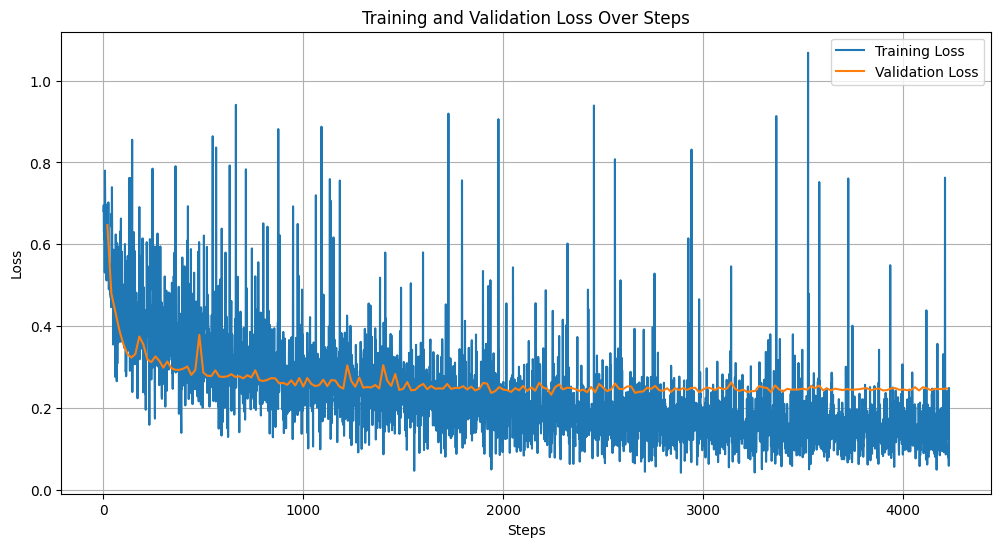

"\n# Plotting evaluation metrics\nplt.figure(figsize=(12, 8))\nfor metric_name, values in eval_metrics.items():\n    if values: # Only plot if there are values for the metric\n        plt.plot(eval_steps, values, label=metric_name)\n\nplt.xlabel('Steps')\nplt.ylabel('Metric Value')\nplt.title('Validation Metrics Over Steps')\nplt.legend()\nplt.grid(True)\nplt.show()\n"

In [18]:
import matplotlib.pyplot as plt

# Extract training and evaluation logs
log_history = trainer.state.log_history

train_losses = []
eval_losses = []
steps = []

# Metrics to plot
eval_metrics = {
    'eval_loss': [],
    'eval_mean_iou': [],
    'eval_accuracy_background': [],
    'eval_accuracy_road': [],
    'eval_iou_background': [],
    'eval_iou_road': [],
}

for log in log_history:
    if 'loss' in log: # Training loss
        train_losses.append(log['loss'])
        steps.append(log['step'])
    if 'eval_loss' in log: # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        for key in eval_metrics.keys():
            if key in log:
                eval_metrics[key].append(log[key])

# Plotting training and evaluation loss
plt.figure(figsize=(12, 6))
plt.plot(steps[:len(train_losses)], train_losses, label='Training Loss')

# Match eval_losses to the steps where evaluation happened
eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]
plt.plot(eval_steps, eval_losses, label='Validation Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Steps')
plt.legend()
plt.grid(True)
plt.show()
'''
# Plotting evaluation metrics
plt.figure(figsize=(12, 8))
for metric_name, values in eval_metrics.items():
    if values: # Only plot if there are values for the metric
        plt.plot(eval_steps, values, label=metric_name)

plt.xlabel('Steps')
plt.ylabel('Metric Value')
plt.title('Validation Metrics Over Steps')
plt.legend()
plt.grid(True)
plt.show()
'''

/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


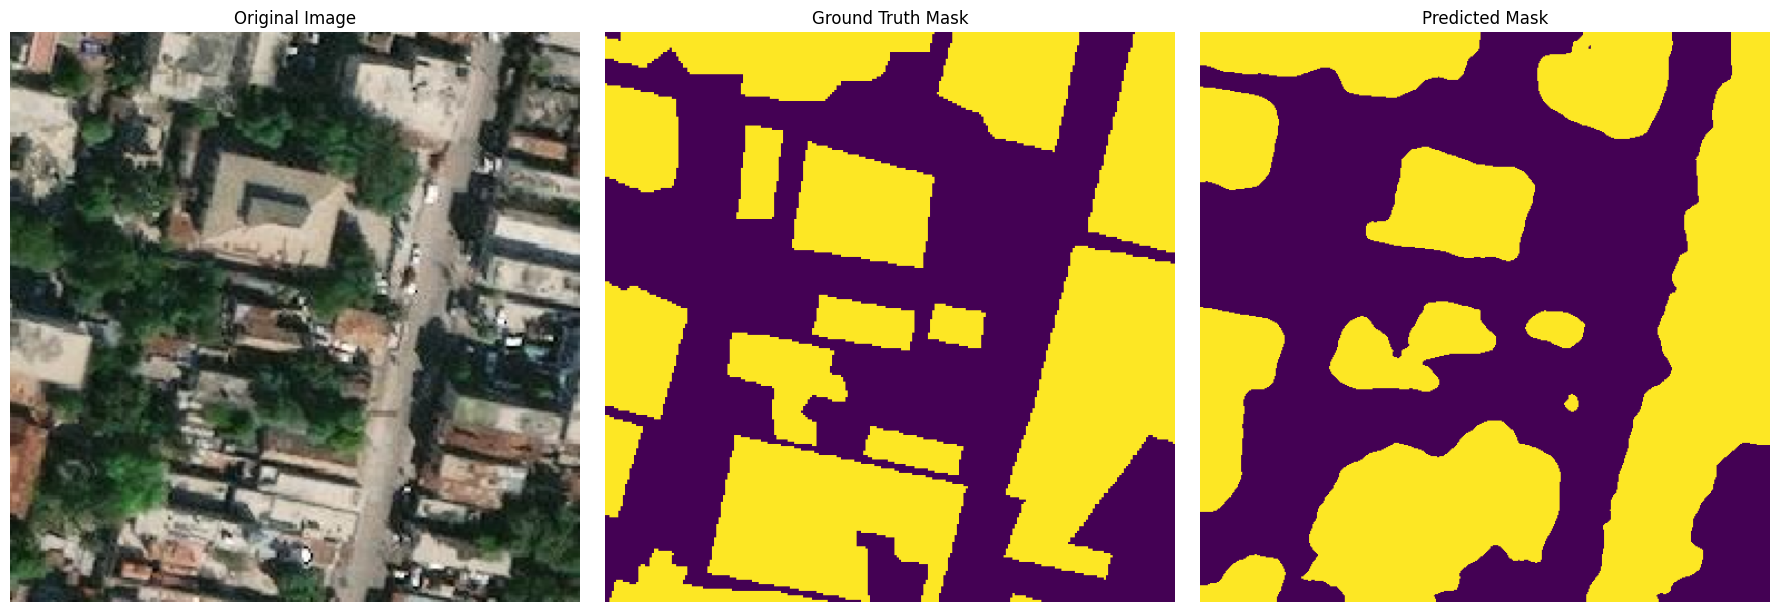

In [22]:
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# Get a sample from the validation dataset
val_dataset = dataloader['val']

# Randomly select an index
idx = 0#random.randint(0, len(val_dataset) - 1)

# Get the item from the dataset
sample = val_dataset[idx]
image_tensor = sample['pixel_values']
label_tensor = sample['labels']

# Retrieve the original image and label paths for better visualization reference
original_image_path = val_dataset.image_paths[idx]
original_label_path = val_dataset.label_paths[idx]

# Load and preprocess the original image for display (without normalization/tensor conversion)
# The `image_tensor` is already normalized and ready for the model.
# We need the original, denormalized image for visual comparison.
original_image_display = Image.open(original_image_path)

# Move image tensor to the correct device for inference
inputs = image_tensor.unsqueeze(0).to(device) # Add batch dimension

# Perform inference
model.eval()
with torch.no_grad():
    outputs = model(inputs)

# Get predicted logits and convert to predicted labels
logits = outputs.logits

# Resize logits to the original label size (from the dataset item) for comparison
# and then take argmax to get class predictions
predicted_mask_tensor = torch.nn.functional.interpolate(
    logits,
    size=label_tensor.shape[-2:], # target size is H, W of the ground truth label
    mode="bilinear",
    align_corners=False
).argmax(dim=1).squeeze(0)

predicted_mask_np = predicted_mask_tensor.cpu().numpy()

# Ground truth mask (from the dataset item, already preprocessed and resized)
# Add a channel dimension for masks_to_colorimg to work correctly (expects C, H, W)
ground_truth_mask_np = label_tensor.unsqueeze(0).cpu().numpy()

# Convert masks to color images using the defined function
colored_ground_truth = np.transpose(ground_truth_mask_np, (1, 2, 0))
colored_prediction = predicted_mask_np#.reshape(1, *predicted_mask_np.shape) # dont Reshape to (1, H, W)

# Plot the original image, ground truth, and prediction
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(colored_ground_truth)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(colored_prediction)
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


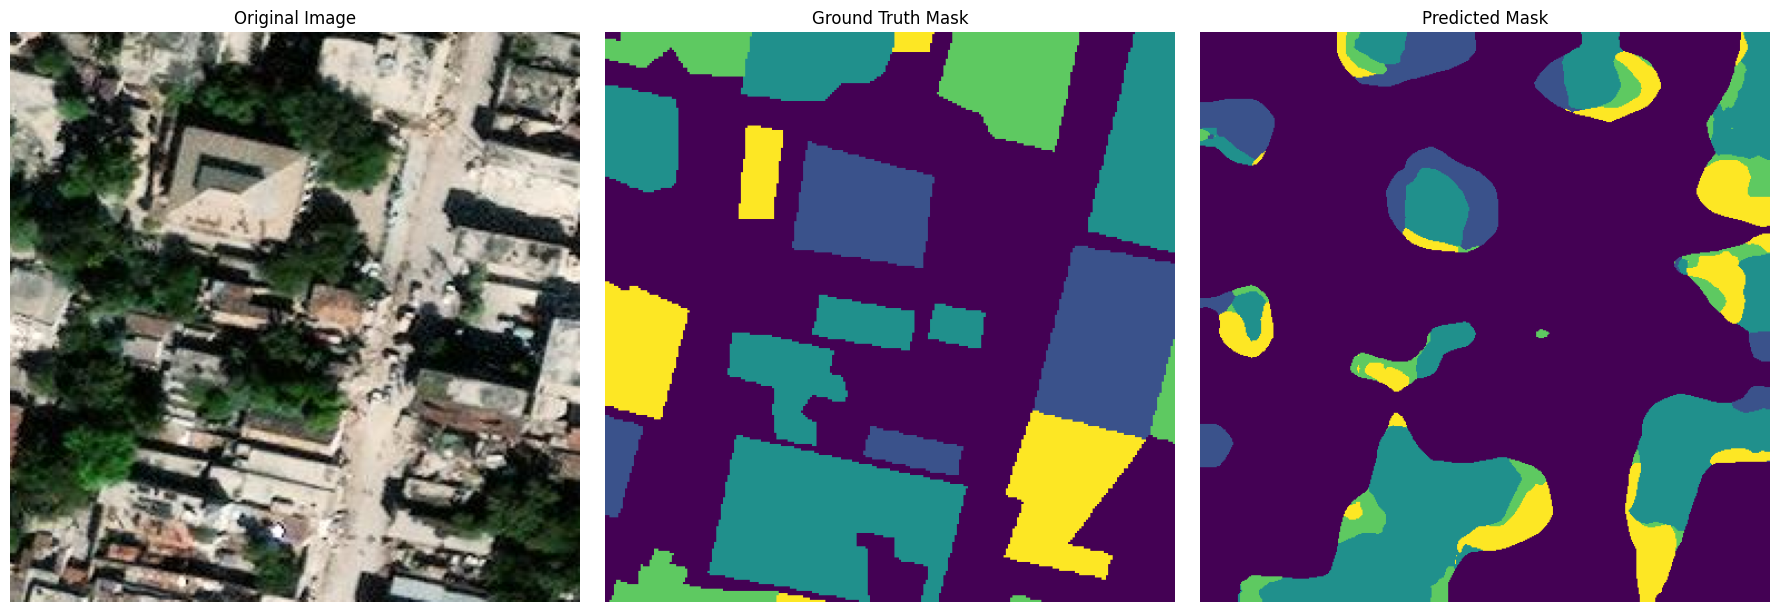

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# Get a sample from the validation dataset
val_dataset = dataloader_phase2['val']

# Randomly select an index
idx = 0#random.randint(0, len(val_dataset) - 1)

# Get the item from the dataset
sample = val_dataset[idx]
image_tensor = sample['pixel_values']
label_tensor = sample['labels']

# Retrieve the original image and label paths for better visualization reference
original_image_path = val_dataset.image_paths[idx]
original_label_path = val_dataset.label_paths[idx]

# Load and preprocess the original image for display (without normalization/tensor conversion)
# The `image_tensor` is already normalized and ready for the model.
# We need the original, denormalized image for visual comparison.
original_image_display = Image.open(original_image_path)

# Move image tensor to the correct device for inference
inputs = image_tensor.unsqueeze(0).to(device) # Add batch dimension

# Perform inference
model_phase2.eval()
with torch.no_grad():
    outputs = model_phase2(inputs)

# Get predicted logits and convert to predicted labels
logits = outputs.logits

# Resize logits to the original label size (from the dataset item) for comparison
# and then take argmax to get class predictions
predicted_mask_tensor = torch.nn.functional.interpolate(
    logits,
    size=label_tensor.shape[-2:], # target size is H, W of the ground truth label
    mode="bilinear",
    align_corners=False
).argmax(dim=1).squeeze(0)

predicted_mask_np = predicted_mask_tensor.cpu().numpy()

# Ground truth mask (from the dataset item, already preprocessed and resized)
# Add a channel dimension for masks_to_colorimg to work correctly (expects C, H, W)
ground_truth_mask_np = label_tensor.unsqueeze(0).cpu().numpy()

# Convert masks to color images using the defined function
colored_ground_truth = np.transpose(ground_truth_mask_np, (1, 2, 0))
colored_prediction = predicted_mask_np#.reshape(1, *predicted_mask_np.shape) # dont Reshape to (1, H, W)

# Plot the original image, ground truth, and prediction
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(colored_ground_truth)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(colored_prediction)
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

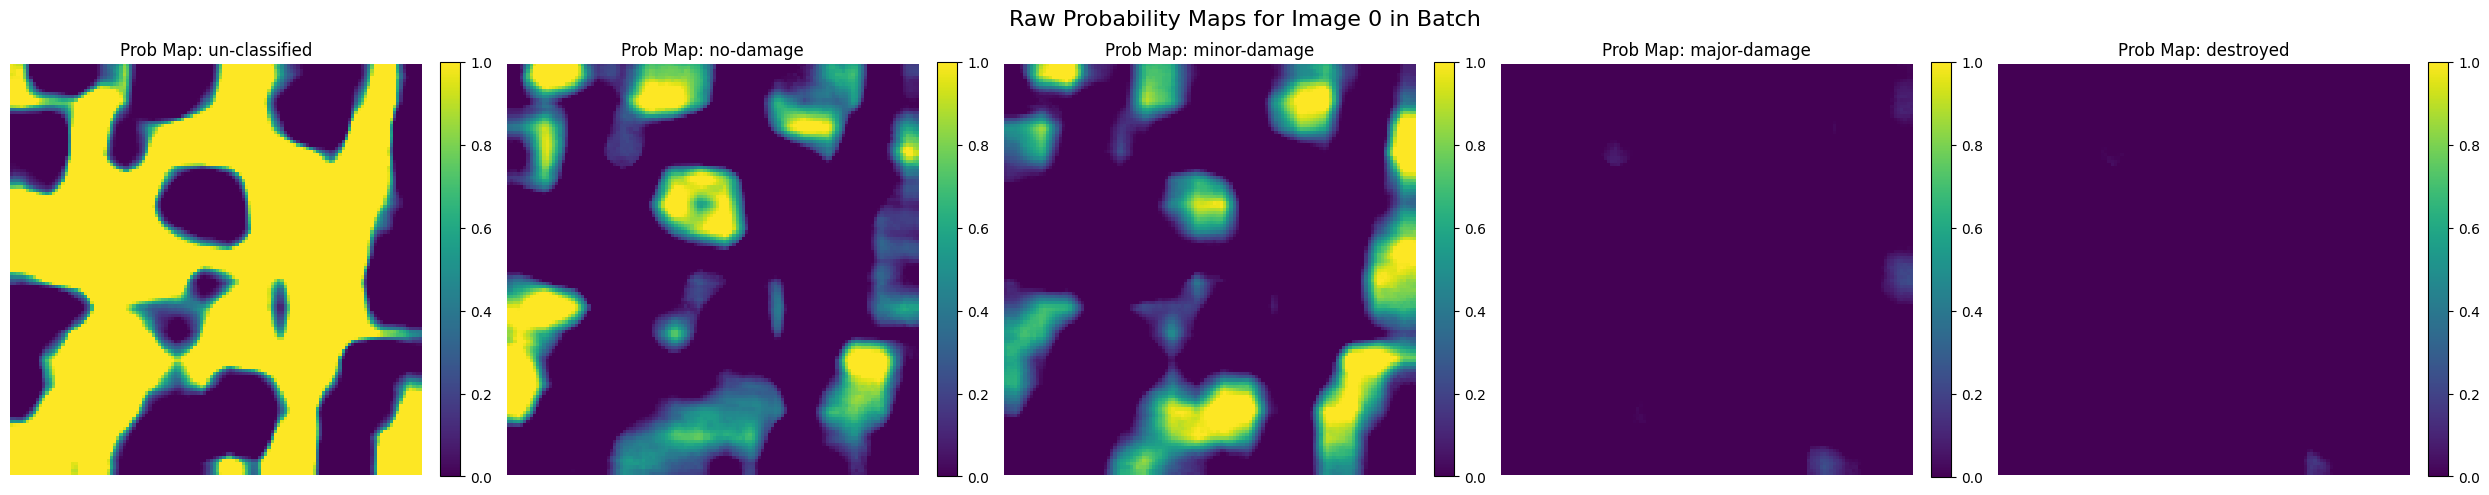

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_probability_maps(predictions, damage_to_idx, image_index=0):
    """
    Plots the raw probability maps for each class from the model's predictions.

    Args:
        predictions (torch.Tensor or np.ndarray): Model output tensor of shape
                                                  (batch_size, num_classes, H, W).
        damage_to_idx (dict): Dictionary mapping damage type names to class indices.
        image_index (int): The index of the image in the batch to visualize.
    """
    # Ensure predictions is a NumPy array
    if isinstance(predictions, torch.Tensor):
        predictions = predictions.cpu().numpy()

    batch_size, num_classes, height, width = predictions.shape

    if image_index >= batch_size:
        print(f"Warning: image_index {image_index} is out of bounds for batch size {batch_size}. Using image_index 0.")
        image_index = 0

    fig, axes = plt.subplots(1, num_classes, figsize=(num_classes * 5, 5))
    if num_classes == 1: # Handle case with a single class
        axes = [axes]

    # Invert the damage_to_idx to get class name from index for titles
    idx_to_damage = {v: k for k, v in damage_to_idx.items()}

    for class_idx in range(num_classes):
        ax = axes[class_idx]
        class_name = idx_to_damage.get(class_idx, f'Class {class_idx}')

        # Extract the probability map for the current class and image
        prob_map = predictions[image_index, class_idx, :, :]

        im = ax.imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'Prob Map: {class_name}')
        ax.axis('off')

        # Add a colorbar for each subplot
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.suptitle(f'Raw Probability Maps for Image {image_index} in Batch', y=1.02, fontsize=16)
    plt.show()

# Call the function with the 'pred' tensor and 'damage_to_idx'
# Assuming 'pred' and 'damage_to_idx' are available from previous execution

# Perform inference
model_phase2.eval()
with torch.no_grad():
    outputs = model_phase2(inputs)

# Get predicted logits and convert to predicted labels
logits = outputs.logits

# Resize logits to the original label size (from the dataset item) for comparison
# and then take argmax to get class predictions
predicted_mask_tensor = torch.nn.functional.interpolate(
    logits,
    size=label_tensor.shape[-2:], # target size is H, W of the ground truth label
    mode="bilinear",
    align_corners=False
).argmax(dim=1).squeeze(0)

predicted_mask_np = predicted_mask_tensor.cpu().numpy()


plot_probability_maps(logits, label2id)


In [35]:
import torch
import numpy as np

class SegmentationMetrics:
    """
    Accumulates a confusion matrix over the full val set,
    then computes per-class and mean IoU + F1.
    """
    def __init__(self, num_classes: int, class_names: list[str], ignore_index: int = 255):
        self.num_classes = num_classes
        self.class_names = class_names
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """
        preds:   (B, H, W) — argmax class indices
        targets: (B, H, W) — ground truth class indices
        """
        preds = preds.cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()

        # Mask out ignored pixels
        mask = targets != self.ignore_index
        preds, targets = preds[mask], targets[mask]

        # Accumulate into confusion matrix
        indices = self.num_classes * targets + preds
        counts = np.bincount(indices, minlength=self.num_classes ** 2)
        self.confusion_matrix += counts.reshape(self.num_classes, self.num_classes)

    def compute(self) -> dict:
        cm = self.confusion_matrix  # shape: (C, C)

        # Per-class IoU
        tp = np.diag(cm)                          # true positives per class
        fp = cm.sum(axis=0) - tp                  # false positives
        fn = cm.sum(axis=1) - tp                  # false negatives

        iou = tp / (tp + fp + fn + 1e-6)

        # Per-class F1
        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        results = {
            "per_class_iou":  dict(zip(self.class_names, iou)),
            "per_class_f1":   dict(zip(self.class_names, f1)),
            "miou":           float(np.mean(iou)),
            "mean_f1":        float(np.mean(f1)),
        }
        return results

#calcualte metrics
dataloader = get_data_loaders(use_pre_disaster=False) # Use post-disaster images for damage classification evaluation
# Get a sample from the validation dataset
val_loader = dataloader['val']
metrics_calculator = SegmentationMetrics(num_classes=5, class_names=list(id2label.values()), ignore_index=0) # Fixed num_classes to 5 and used id2label.values()
#iterate through entire val dataset and calculate mIoU for each class and mean IoU
ious_per_class = []
mean_ious = []
for batch in val_loader:
    inputs = batch["pixel_values"].to(device)
    labels = batch["labels"].to(device)

    with torch.no_grad():
        outputs = model_phase2(inputs)

    # Get predicted logits and convert to predicted labels
    logits = outputs.logits

    predicted_mask_tensor = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:], # target size is H, W of the ground truth label
        mode="bilinear",
        align_corners=False
    ).argmax(dim=1)

    # labels are already 0 or 1 from TrainingDataset
    # No need for F.softmax or remap_labels as per user request and dataset prep

    # Update IoU metrics
    metrics_calculator.update(predicted_mask_tensor.cpu(), labels.cpu())

results = metrics_calculator.compute()
print("Per-class IoU:", results["per_class_iou"])
print("Per-class F1:", results["per_class_f1"])
print("Mean IoU:", results["miou"])
print("Mean F1:", results["mean_f1"])


Training images: 281
Validation images: 71
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.


/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


Per-class IoU: {'un-classified': np.float64(0.0), 'no-damage': np.float64(0.2850503101614005), 'minor-damage': np.float64(0.3307198795001694), 'major-damage': np.float64(0.0677516204544635), 'destroyed': np.float64(0.1920229006439606)}
Per-class F1: {'un-classified': np.float64(0.0), 'no-damage': np.float64(0.44364021611838345), 'minor-damage': np.float64(0.49705360101518287), 'major-damage': np.float64(0.12690490127687526), 'destroyed': np.float64(0.32217943280874406)}
Mean IoU: 0.17510894215199882
Mean F1: 0.2779556302438372


#HuggingFace article
https://huggingface.co/docs/transformers/en/model_doc/segformer?usage=Pipeline

In [ ]:
from transformers import SegformerModel, SegformerConfig

# Initializing a SegFormer nvidia/segformer-b0-finetuned-ade-512-512 style configuration
configuration = SegformerConfig()

# Initializing a model from the nvidia/segformer-b0-finetuned-ade-512-512 style configuration
model = SegformerModel(configuration)

# Accessing the model configuration
configuration = model.config

#??????

In [31]:
# Pass the inputs to the model
# Unpacking the dictionary directly feeds 'pixel_values' and 'labels' to the model
outputs = model_phase2(inputs)

# The model automatically computes the Cross-Entropy loss because 'labels' were provided
loss = outputs.loss
logits = outputs.logits

print(f"Calculated Loss: {loss.item()}")
print(f"Logits shape: {logits.shape}")

AttributeError: 'NoneType' object has no attribute 'item'

In [28]:
import time
import torch

num_class = 2

dataloader = get_data_loaders(batch_size=10, return_dataset=True)
# Get a sample from the validation dataset
val_loader = dataloader['val']

inputs = val_loader[0]["pixel_values"].to(device)
labels = val_loader[0]["labels"].to(device)

# Ensure batch dimension exists
if inputs.ndim == 3:   # [C,H,W] -> [1,C,H,W]
    inputs = inputs.unsqueeze(0)
if labels.ndim == 2:   # [H,W] -> [1,H,W]
    labels = labels.unsqueeze(0)

latency_calc_device = torch.device("cpu")

idx = 0
print(inputs.shape)

# Move image tensor to the correct device for inference
inputs = inputs.to(latency_calc_device)

model = model.to(latency_calc_device) # Move model to the same device as inputs for latency calculation

model.eval()
with torch.no_grad():
    start_time = time.time()
    output = model(inputs)
    latency = (time.time() - start_time) * 1000 / inputs.size(0)  # in milliseconds

print(f"Inference latency (Averaged across {inputs.size(0)} images): {latency:.2f} ms")

Training images: 281
Validation images: 71
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
torch.Size([1, 3, 512, 512])


/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


Inference latency (Averaged across 1 images): 309.76 ms
